# Feature Space Analysis Example

This notebook demonstrates how to use the feature analysis functions to:
1. Load precomputed features from H5 files
2. Generate UMAP and t-SNE visualizations
3. Calculate intra-class variances and inter-class distances
4. Analyze feature spaces for different transfers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import our feature analysis functions
from model_ranking.feature_analysis import (
    plot_umap_features,
    plot_tsne_features,
    calculate_intra_class_variance,
    calculate_inter_class_distances,
    analyze_feature_space,
    reshape_features_for_analysis,
)
from model_ranking.utils import load_h5
from model_ranking.feature_ranking import get_precomputed_feature_path

INFO: P [MainThread] 2025-08-20 17:00:50,306 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load Precomputed Features

First, let's load some precomputed features from a transfer scenario.

In [2]:
# Define the transfer scenario
model_name = "E_model_NA2"
target = "EPFL"
layer_key = "decoders.2"
base_path = "/scratch/talks/sampled_features/semantic_segmentation/mitochondria/1k_pixels_sampled"

# Get the path to the precomputed features
feature_path = get_precomputed_feature_path(model_name, target, base_path, filetype="h5")
print(f"Loading features from: {feature_path}")

# Load features and labels
features = load_h5(feature_path, f"{layer_key}_features")
labels = load_h5(feature_path, f"{layer_key}_labels")

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Feature dimension: {features.shape[-1]}")

Loading features from: /scratch/talks/sampled_features/semantic_segmentation/mitochondria/1k_pixels_sampled/EPFL_to_EPFL/E_model_NA2_to_EPFL_features.h5
Features shape: (750, 1000, 32)
Labels shape: (750, 1000)
Feature dimension: 32


## 2. Analyze All Patches Together

Let's reshape the features to analyze all patches together.

In [3]:
# find patches that contain some foreground
non_zero_ids = np.where(~np.all(labels == 0, axis=1))[0]
features = features[non_zero_ids]
labels = labels[non_zero_ids]

In [4]:
# Reshape features for analysis (all patches)
features_all, labels_all = reshape_features_for_analysis(features, labels)

# Subsample for visualization (if dataset is large)
max_samples = 10000
if len(features_all) > max_samples:
    indices = np.random.choice(len(features_all), max_samples, replace=False)
    features_subset = features_all[indices]
    labels_subset = labels_all[indices]
else:
    features_subset = features_all
    labels_subset = labels_all

# Print dataset statistics
unique_labels, counts = np.unique(labels_subset, return_counts=True)
print(f"Total samples: {len(features_subset)}")
print(f"Classes: {unique_labels}")
print(f"Class counts: {dict(zip(unique_labels, counts))}")

Analyzing all 712 patches with 712000 total pixels
Total samples: 10000
Classes: [0. 1.]
Class counts: {0.0: 5428, 1.0: 4572}


## 3. Generate UMAP Visualization

Computing UMAP embedding with 10000 samples and 32 features...
UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Aug 20 15:29:00 2025 Construct fuzzy simplicial set
Wed Aug 20 15:29:00 2025 Finding Nearest Neighbors
Wed Aug 20 15:29:00 2025 Building RP forest with 10 trees
Wed Aug 20 15:29:00 2025 NN descent for 13 iterations
	 1  /  13


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Wed Aug 20 15:29:01 2025 Finished Nearest Neighbor Search
Wed Aug 20 15:29:01 2025 Construct embedding


Epochs completed:   2%| ▏          8/500 [00:00]

	completed  0  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  456/500 [00:26]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:28]



Wed Aug 20 15:29:30 2025 Finished embedding


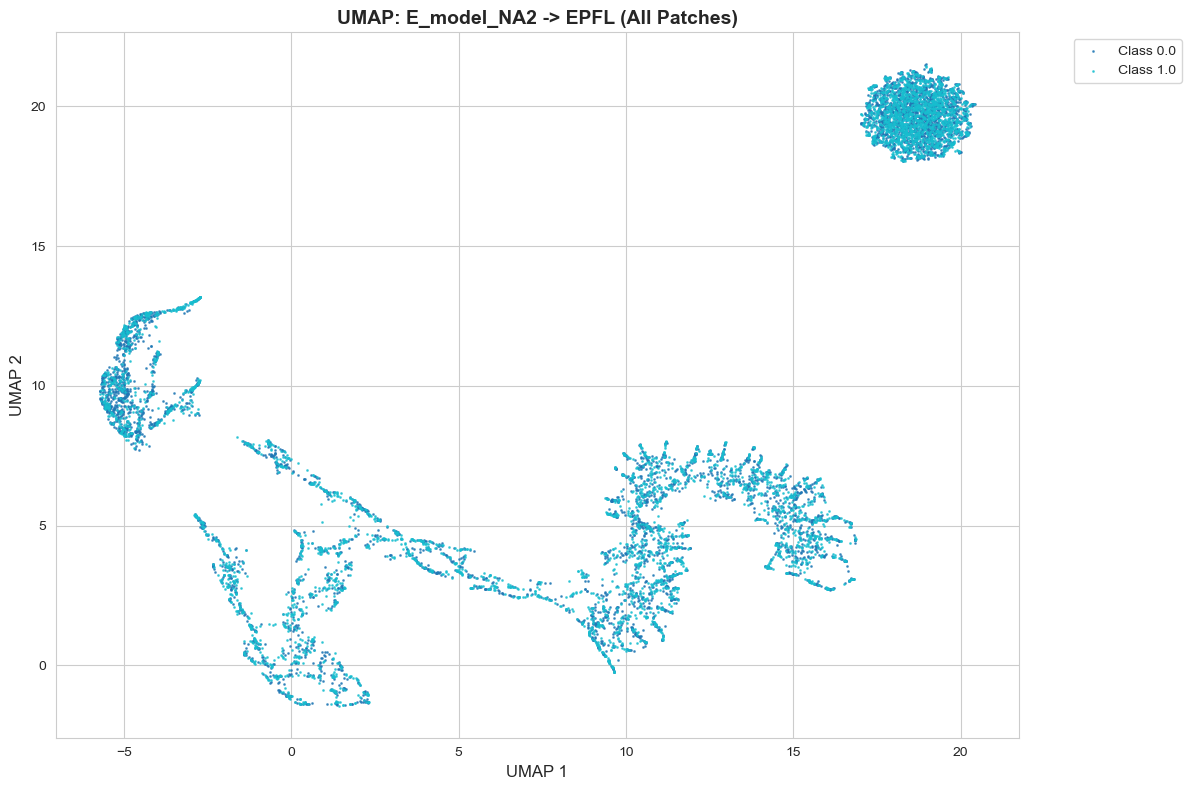

In [23]:
# Create UMAP visualization
umap_fig = plot_umap_features(
    features_subset,
    labels_subset,
    title=f"UMAP: {model_name} -> {target} (All Patches)",
    figsize=(12, 8)
)
plt.show()

## 4. Generate t-SNE Visualization

Computing t-SNE embedding with 10000 samples and 32 features...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.002s...


[t-SNE] Computed neighbors for 10000 samples in 0.449s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 0.000000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilitie

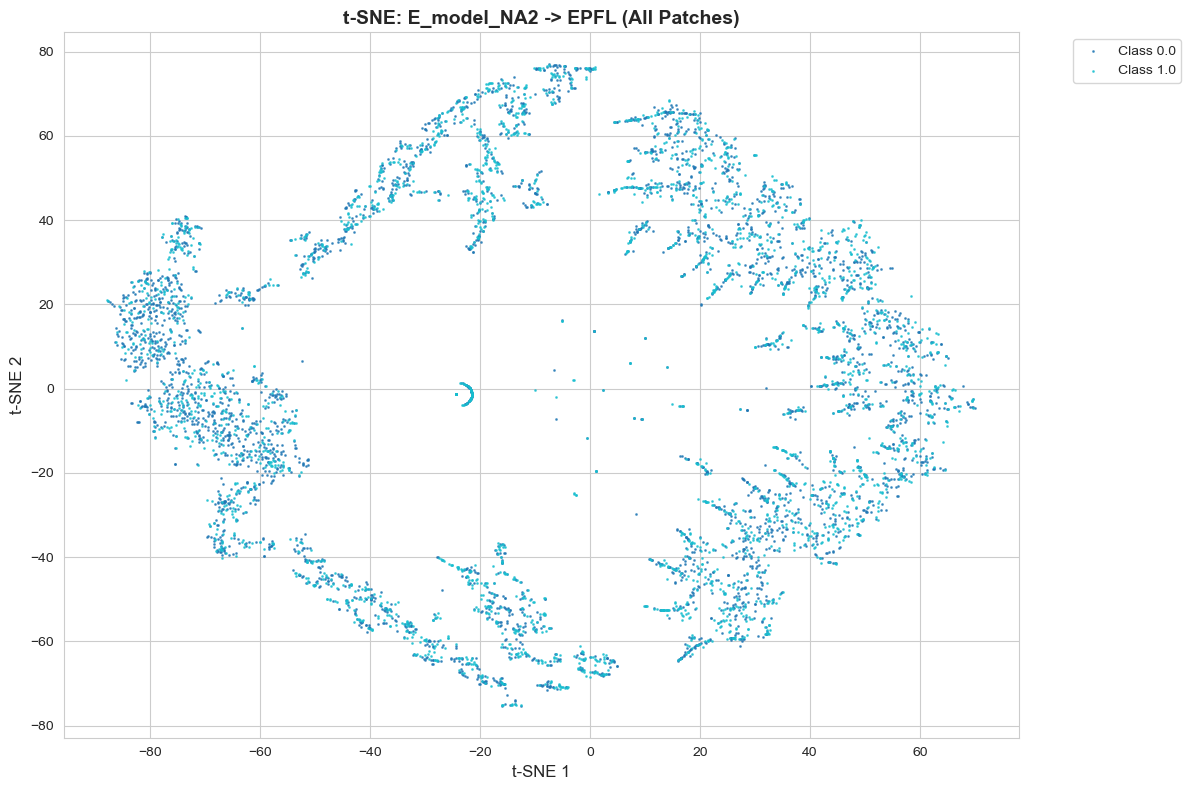

In [8]:
# Create t-SNE visualization
tsne_fig = plot_tsne_features(
    features_subset,
    labels_subset,
    title=f"t-SNE: {model_name} -> {target} (All Patches)",
    figsize=(12, 8)
)
plt.show()

## 5. Calculate Feature Space Statistics

In [9]:
# Calculate intra-class variances
intra_class_vars = calculate_intra_class_variance(features_subset, labels_subset)
print("Intra-class variances:")
for class_label, variance in intra_class_vars.items():
    print(f"  Class {class_label}: {variance:.6f}")

# Calculate inter-class distances
inter_class_dists = calculate_inter_class_distances(features_subset, labels_subset)
print("\nInter-class distances (Euclidean):")
for (class1, class2), distance in inter_class_dists.items():
    print(f"  Class {class1} <-> Class {class2}: {distance:.6f}")

Intra-class variances:
  Class 0: 318.447235
  Class 1: 270.756989

Inter-class distances (Euclidean):
  Class 0 <-> Class 1: 1.802752


## 6. Analyze Single Patch

Let's compare the feature space of a single patch vs. all patches.

In [24]:
# Analyze a single patch (e.g., patch 0)
patch_index = 0
features_patch, labels_patch = reshape_features_for_analysis(features, labels, patch_index=patch_index)

print(f"\n=== Single Patch Analysis (Patch {patch_index}) ===")
print(f"Patch samples: {len(features_patch)}")

# Calculate statistics for single patch
intra_class_vars_patch = calculate_intra_class_variance(features_patch, labels_patch)
inter_class_dists_patch = calculate_inter_class_distances(features_patch, labels_patch)

print("Intra-class variances (single patch):")
for class_label, variance in intra_class_vars_patch.items():
    print(f"  Class {class_label}: {variance:.6f}")

print("Inter-class distances (single patch):")
for (class1, class2), distance in inter_class_dists_patch.items():
    print(f"  Class {class1} <-> Class {class2}: {distance:.6f}")

Analyzing single patch 0 with 1000 pixels

=== Single Patch Analysis (Patch 0) ===
Patch samples: 1000
Intra-class variances (single patch):
  Class 0: 268.285492
  Class 1: 313.590057
Inter-class distances (single patch):
  Class 0 <-> Class 1: 0.697908


Computing UMAP embedding with 1000 samples and 32 features...
UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Aug 20 15:32:20 2025 Construct fuzzy simplicial set


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Wed Aug 20 15:32:21 2025 Finding Nearest Neighbors
Wed Aug 20 15:32:21 2025 Finished Nearest Neighbor Search
Wed Aug 20 15:32:21 2025 Construct embedding


Epochs completed:   2%| ▏          12/500 [00:00]

	completed  0  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  94%| █████████▍ 472/500 [00:03]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:03]



Wed Aug 20 15:32:25 2025 Finished embedding


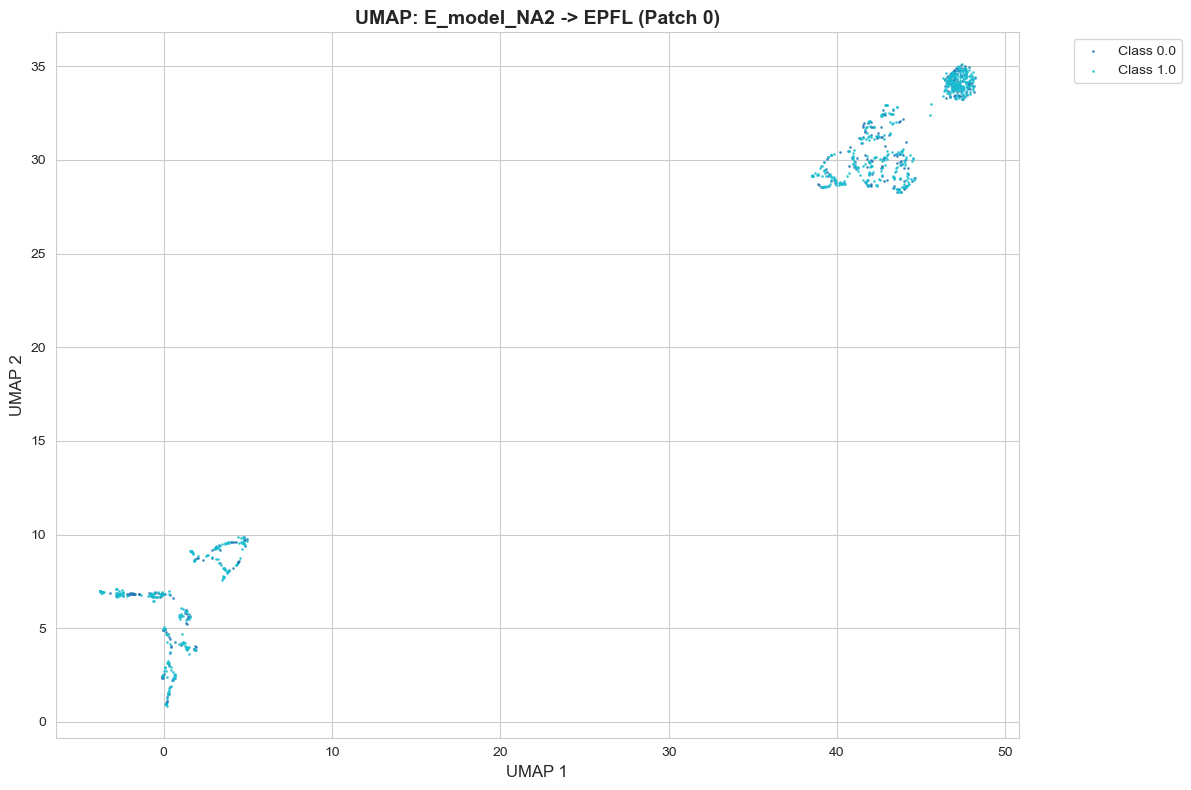

In [25]:
# Visualize single patch
umap_fig_patch = plot_umap_features(
    features_patch,
    labels_patch,
    title=f"UMAP: {model_name} -> {target} (Patch {patch_index})",
    figsize=(12, 8)
)
plt.show()

## 7. Compare Multiple Transfers

Let's compare feature spaces across different source models.

In [12]:
# Define multiple transfers to compare
transfers = [
    {"model": "E_model_NA2", "target": "EPFL", "label": "EPFL->EPFL"},
    {"model": "V_model_Res1", "target": "EPFL", "label": "VNC->EPFL"},
    # Add more transfers as needed
]

transfer_results = {}

for transfer in transfers:
    try:
        # Load features
        feature_path = get_precomputed_feature_path(
            transfer["model"], transfer["target"], base_path, filetype="h5"
        )
        features_t = load_h5(feature_path, f"{layer_key}_features")
        labels_t = load_h5(feature_path, f"{layer_key}_labels")
        
        # Reshape and subsample
        features_t, labels_t = reshape_features_for_analysis(features_t, labels_t)
        if len(features_t) > max_samples:
            indices = np.random.choice(len(features_t), max_samples, replace=False)
            features_t = features_t[indices]
            labels_t = labels_t[indices]
        
        # Calculate statistics
        intra_vars = calculate_intra_class_variance(features_t, labels_t)
        inter_dists = calculate_inter_class_distances(features_t, labels_t)
        
        transfer_results[transfer["label"]] = {
            "intra_class_vars": intra_vars,
            "inter_class_dists": inter_dists,
            "features": features_t,
            "labels": labels_t
        }
        
        print(f"\n=== {transfer['label']} ===")
        print(f"Samples: {len(features_t)}")
        print("Intra-class variances:")
        for class_label, variance in intra_vars.items():
            print(f"  Class {class_label}: {variance:.6f}")
            
    except Exception as e:
        print(f"Error processing {transfer['label']}: {e}")

Analyzing all 750 patches with 750000 total pixels

=== EPFL->EPFL ===
Samples: 10000
Intra-class variances:
  Class 0: 311.398254
  Class 1: 274.862335
Error processing VNC->EPFL: "Unable to synchronously open object (object 'decoders.2_features' doesn't exist)"


## 8. Comprehensive Analysis with Saved Results

Use the all-in-one analysis function that saves results.

In [5]:
# Run comprehensive analysis and save results
output_dir = f"./test_feature_analysis/feature_analysis_{model_name}_to_{target}"

results = analyze_feature_space(
    features_subset,
    labels_subset,
    title_prefix=f"{model_name} -> {target}",
    save_dir=output_dir
)

print(f"\nAnalysis complete! Results saved to: {output_dir}")

Analyzing feature space with 10000 samples and 32 features...
Calculating intra-class variances...
Calculating inter-class distances...
Calculating silhouette score...
Overall silhouette score: -0.0048

Silhouette Score Analysis:
  Overall score: -0.0048

=== Feature Space Analysis Results ===
Intra-class variances:
  Class 0: 316.564789
  Class 1: 276.090942

Inter-class distances (Euclidean):
  Class 0 <-> Class 1: 1.607435

Generating UMAP visualization...
Computing UMAP embedding with 10000 samples and 32 features...
UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Aug 20 17:00:59 2025 Construct fuzzy simplicial set
Wed Aug 20 17:00:59 2025 Finding Nearest Neighbors
Wed Aug 20 17:00:59 2025 Building RP forest with 10 trees


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Wed Aug 20 17:01:02 2025 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	 5  /  13
	Stopping threshold met -- exiting after 5 iterations
Wed Aug 20 17:01:09 2025 Finished Nearest Neighbor Search
Wed Aug 20 17:01:11 2025 Construct embedding


Epochs completed:   1%|            6/500 [00:00]

	completed  0  /  500 epochs


...

	completed  400  /  500 epochs


Epochs completed:  91%| █████████  456/500 [00:27]

	completed  450  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:30]


Wed Aug 20 17:01:42 2025 Finished embedding
UMAP plot saved to ./test_feature_analysis/feature_analysis_E_model_NA2_to_EPFL/umap_visualization.png
Generating t-SNE visualization...
Computing t-SNE embedding with 10000 samples and 32 features...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.000s...
[t-SNE] Computed neighbors for 10000 samples in 0.328s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] C